In [2]:
# ── Imports ────────────────────────────────────────────
import warnings
from datetime import timedelta
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

print("All imports loaded!")

/Users/devikrishna/Desktop/Projects/Retail_IQ/RetailIQ_Platform/.venv/lib/python3.11/site-packages/mlflow/utils/requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251


All imports loaded!


In [3]:
# ── Load data ──────────────────────────────────────────
df = pd.read_parquet("../data/retail_clean.parquet")
df["invoicedate"] = pd.to_datetime(df["invoicedate"])
segments = pd.read_parquet("../data/segments.parquet")

# ── Observation / Outcome split ────────────────────────
data_end    = df["invoicedate"].max()
cutoff_date = data_end - timedelta(days=90)
df_observe  = df[df["invoicedate"] <= cutoff_date].copy()
df_outcome  = df[df["invoicedate"] >  cutoff_date].copy()

observe_customers = set(df_observe["customer_id"].unique())
outcome_customers = set(df_outcome["customer_id"].unique())

# ── Churn labels ───────────────────────────────────────
churn_labels = pd.DataFrame({"customer_id": list(observe_customers)})
churn_labels["churned"] = churn_labels["customer_id"].apply(
    lambda x: 0 if x in outcome_customers else 1
)

# ── Features ───────────────────────────────────────────
reference_date = cutoff_date

features = (
    df_observe.groupby("customer_id")
    .agg(
        recency=("invoicedate", lambda x: (reference_date - x.max()).days),
        frequency=("invoice", "nunique"),
        monetary=("revenue", "sum"),
        avg_order_value=("revenue", "mean"),
        avg_quantity=("quantity", "mean"),
        unique_products=("stockcode", "nunique"),
        total_items=("quantity", "sum"),
        tenure_days=("invoicedate", lambda x: (x.max() - x.min()).days),
        total_orders=("invoice", "nunique"),
        is_uk=("is_uk", "first"),
    )
    .reset_index()
)

features["avg_days_between_orders"] = np.where(
    features["total_orders"] > 1,
    features["tenure_days"] / (features["total_orders"] - 1),
    0
)
features["revenue_per_product"] = features["monetary"] / features["unique_products"].clip(lower=1)
features["items_per_order"] = features["total_items"] / features["total_orders"].clip(lower=1)
features["monetary_log"]  = np.log1p(features["monetary"])
features["frequency_log"] = np.log1p(features["frequency"])

# ── Merge ──────────────────────────────────────────────
model_df = features.merge(churn_labels, on="customer_id", how="inner")
model_df = model_df.merge(
    segments[["customer_id", "segment_name"]], on="customer_id", how="left"
)
model_df["segment_name"] = model_df["segment_name"].fillna("Unknown")

# ── Split ──────────────────────────────────────────────
exclude_cols = ["customer_id", "churned", "segment_name"]
numeric_features = [c for c in model_df.columns
                    if c not in exclude_cols
                    and model_df[c].dtype in ["int64", "float64", "Int64"]]
categorical_features = ["segment_name"]

X = model_df[numeric_features + categorical_features]
y = model_df["churned"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"Churn rate: {y.mean():.3f}")

Train: 3,696 | Val: 792 | Test: 793
Churn rate: 0.566


In [4]:
# ── Preprocessor (reusable across all models) ──────────
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler",  StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                ("encoder", OneHotEncoder(drop="first", sparse_output=False,
                                          handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ]
)


def evaluate_model(name, pipeline, X_tr, y_tr, X_v, y_v, log_mlflow=True):
    """Train, evaluate, and optionally log to MLflow."""
    pipeline.fit(X_tr, y_tr)

    y_train_prob = pipeline.predict_proba(X_tr)[:, 1]
    y_val_prob   = pipeline.predict_proba(X_v)[:, 1]
    y_val_pred   = pipeline.predict(X_v)

    metrics = {
        "roc_auc_train": round(roc_auc_score(y_tr, y_train_prob), 4),
        "roc_auc_val":   round(roc_auc_score(y_v, y_val_prob), 4),
        "pr_auc_val":    round(average_precision_score(y_v, y_val_prob), 4),
        "f1_val":        round(f1_score(y_v, y_val_pred), 4),
        "accuracy_val":  round(accuracy_score(y_v, y_val_pred), 4),
    }

    if log_mlflow:
        with mlflow.start_run(run_name=name):
            for k, v in metrics.items():
                mlflow.log_metric(k, v)
            mlflow.sklearn.log_model(pipeline, "model")

    print(f"\n{'─' * 50}")
    print(f"  {name}")
    print(f"{'─' * 50}")
    for k, v in metrics.items():
        print(f"  {k:20s}: {v}")

    return pipeline, metrics, y_val_prob


print("Helper function ready!")

Helper function ready!


In [5]:
# ── MLflow setup ───────────────────────────────────────
mlflow.set_tracking_uri("file:///" + str(Path("../mlruns").resolve()))
mlflow.set_experiment("churn_prediction")

results = {}

# ── 1. Logistic Regression (baseline) ─────────────────
lr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000, random_state=42, class_weight="balanced"
    )),
])
lr_pipe, results["LR"], lr_probs = evaluate_model(
    "Logistic Regression", lr_pipe, X_train, y_train, X_val, y_val
)

# ── 2. Random Forest ──────────────────────────────────
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=5,
        class_weight="balanced", random_state=42, n_jobs=-1
    )),
])
rf_pipe, results["RF"], rf_probs = evaluate_model(
    "Random Forest", rf_pipe, X_train, y_train, X_val, y_val
)

# ── 3. XGBoost ────────────────────────────────────────
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        scale_pos_weight=scale_pos,
        eval_metric="logloss", random_state=42, n_jobs=-1
    )),
])
xgb_pipe, results["XGB"], xgb_probs = evaluate_model(
    "XGBoost", xgb_pipe, X_train, y_train, X_val, y_val
)

# ── 4. LightGBM ──────────────────────────────────────
lgbm_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", lgb.LGBMClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        is_unbalance=True, random_state=42, n_jobs=-1, verbose=-1
    )),
])
lgbm_pipe, results["LGBM"], lgbm_probs = evaluate_model(
    "LightGBM", lgbm_pipe, X_train, y_train, X_val, y_val
)

# ── Summary table ─────────────────────────────────────
print("\n\n═══════════════════════════════════════════════════")
print("  MODEL COMPARISON")
print("═══════════════════════════════════════════════════")
comparison = pd.DataFrame(results).T
print(comparison.to_string())


──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
  roc_auc_train       : 0.8998
  roc_auc_val         : 0.9046
  pr_auc_val          : 0.9366
  f1_val              : 0.8015
  accuracy_val        : 0.8018

──────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────
  roc_auc_train       : 0.9809
  roc_auc_val         : 0.9425
  pr_auc_val          : 0.9612
  f1_val              : 0.8651
  accuracy_val        : 0.8535

──────────────────────────────────────────────────
  XGBoost
──────────────────────────────────────────────────
  roc_auc_train       : 0.9998
  roc_auc_val         : 0.9426
  pr_auc_val          : 0.9597
  f1_val              : 0.8588
  accuracy_val        : 0.8422

──────────────────────────────────────────────────
  LightGBM
──────────────────────────────────────────────────
  roc_auc_train       : 0.9999
  roc_auc_val         : 0.9397
  

In [6]:
# ══════════════════════════════════════════════════════════
# SMOTE vs class_weight — which handles imbalance better?
# ══════════════════════════════════════════════════════════
# SMOTE creates SYNTHETIC minority samples by interpolating
# between existing churned customers. It runs AFTER preprocessing
# but BEFORE the model — only on training data.
# ══════════════════════════════════════════════════════════

# Preprocess first (SMOTE needs numeric data)
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed   = preprocessor.transform(X_val)

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print(f"Before SMOTE: {len(X_train_processed):,} rows | Churn rate: {y_train.mean():.3f}")
print(f"After SMOTE : {len(X_train_smote):,} rows | Churn rate: {y_train_smote.mean():.3f}")

# Train LightGBM on SMOTE data
lgbm_smote = lgb.LGBMClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.1,
    random_state=42, n_jobs=-1, verbose=-1
)
lgbm_smote.fit(X_train_smote, y_train_smote)

y_smote_prob = lgbm_smote.predict_proba(X_val_processed)[:, 1]
y_smote_pred = lgbm_smote.predict(X_val_processed)

smote_metrics = {
    "roc_auc_val": round(roc_auc_score(y_val, y_smote_prob), 4),
    "pr_auc_val":  round(average_precision_score(y_val, y_smote_prob), 4),
    "f1_val":      round(f1_score(y_val, y_smote_pred), 4),
}

with mlflow.start_run(run_name="LightGBM + SMOTE"):
    for k, v in smote_metrics.items():
        mlflow.log_metric(k, v)

print(f"\n── SMOTE Results ───────────────────────────────")
for k, v in smote_metrics.items():
    print(f"  {k:20s}: {v}")

print(f"\n── class_weight vs SMOTE ────────────────────────")
print(f"  LGBM (is_unbalance)  ROC-AUC: {results['LGBM']['roc_auc_val']}")
print(f"  LGBM (SMOTE)         ROC-AUC: {smote_metrics['roc_auc_val']}")

Before SMOTE: 3,696 rows | Churn rate: 0.566
After SMOTE : 4,184 rows | Churn rate: 0.500

── SMOTE Results ───────────────────────────────
  roc_auc_val         : 0.9392
  pr_auc_val          : 0.9569
  f1_val              : 0.8565

── class_weight vs SMOTE ────────────────────────
  LGBM (is_unbalance)  ROC-AUC: 0.9397
  LGBM (SMOTE)         ROC-AUC: 0.9392


In [7]:
# ══════════════════════════════════════════════════════════
# OPTUNA — Bayesian hyperparameter search
# Tries 100 combinations intelligently (not random/grid)
# ══════════════════════════════════════════════════════════

def objective(trial):
    """Optuna objective: maximise ROC-AUC on validation set."""
    params = {
        "n_estimators":   trial.suggest_int("n_estimators", 100, 500),
        "max_depth":      trial.suggest_int("max_depth", 3, 10),
        "learning_rate":  trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves":     trial.suggest_int("num_leaves", 20, 100),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample":      trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":      trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":     trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }

    model = lgb.LGBMClassifier(
        **params,
        is_unbalance=True,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    model.fit(X_train_processed, y_train)
    y_prob = model.predict_proba(X_val_processed)[:, 1]
    return roc_auc_score(y_val, y_prob)


# Run 100 trials
study = optuna.create_study(direction="maximize", study_name="lgbm_churn")
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\n── Optuna Results ──────────────────────────────")
print(f"Best ROC-AUC : {study.best_value:.4f}")
print(f"Best params  :")
for k, v in study.best_params.items():
    print(f"  {k:25s}: {v}")

  0%|          | 0/100 [00:00<?, ?it/s]


── Optuna Results ──────────────────────────────
Best ROC-AUC : 0.9504
Best params  :
  n_estimators             : 139
  max_depth                : 4
  learning_rate            : 0.09204774228345804
  num_leaves               : 25
  min_child_samples        : 34
  subsample                : 0.683244951918649
  colsample_bytree         : 0.8536805936721437
  reg_alpha                : 0.001024896089780998
  reg_lambda               : 0.2839831055698504


In [8]:
# ── Train final model with best params ─────────────────
best_lgbm = lgb.LGBMClassifier(
    **study.best_params,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
best_lgbm.fit(X_train_processed, y_train)

y_champion_prob = best_lgbm.predict_proba(X_val_processed)[:, 1]
y_champion_pred = best_lgbm.predict(X_val_processed)

champion_metrics = {
    "roc_auc_val": round(roc_auc_score(y_val, y_champion_prob), 4),
    "pr_auc_val":  round(average_precision_score(y_val, y_champion_prob), 4),
    "f1_val":      round(f1_score(y_val, y_champion_pred), 4),
    "accuracy_val": round(accuracy_score(y_val, y_champion_pred), 4),
}

# Log to MLflow
with mlflow.start_run(run_name="LightGBM — Optuna Champion"):
    for k, v in champion_metrics.items():
        mlflow.log_metric(k, v)
    for k, v in study.best_params.items():
        mlflow.log_param(k, v)

print("── Champion Model (Tuned LightGBM) ─────────────")
for k, v in champion_metrics.items():
    print(f"  {k:20s}: {v}")

print(f"\n── Improvement over baseline LR ─────────────────")
print(f"  LR       ROC-AUC: {results['LR']['roc_auc_val']}")
print(f"  Champion ROC-AUC: {champion_metrics['roc_auc_val']}")
print(f"  Δ AUC          : {champion_metrics['roc_auc_val'] - results['LR']['roc_auc_val']:+.4f}")

── Champion Model (Tuned LightGBM) ─────────────
  roc_auc_val         : 0.9504
  pr_auc_val          : 0.9652
  f1_val              : 0.8787
  accuracy_val        : 0.8699

── Improvement over baseline LR ─────────────────
  LR       ROC-AUC: 0.9046
  Champion ROC-AUC: 0.9504
  Δ AUC          : +0.0458


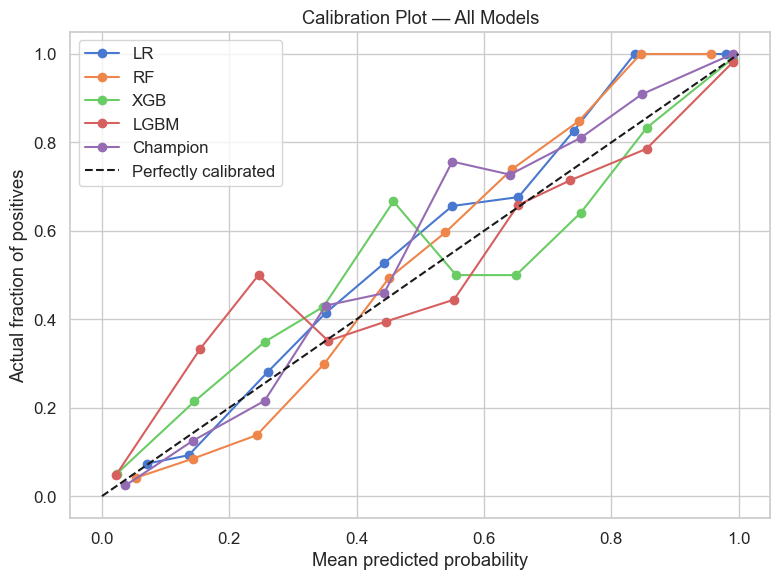

In [9]:
# ══════════════════════════════════════════════════════════
# CALIBRATION — Does "70% churn probability" really mean
# 70% of those customers churn?
# ══════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(8, 6))

# Plot for each model
models_to_calibrate = {
    "LR":       lr_probs,
    "RF":       rf_probs,
    "XGB":      xgb_probs,
    "LGBM":     lgbm_probs,
    "Champion": y_champion_prob,
}

for name, probs in models_to_calibrate.items():
    prob_true, prob_pred = calibration_curve(y_val, probs, n_bins=10)
    ax.plot(prob_pred, prob_true, marker="o", label=name)

ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Actual fraction of positives")
ax.set_title("Calibration Plot — All Models")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/09_calibration.png", dpi=150)
plt.show()

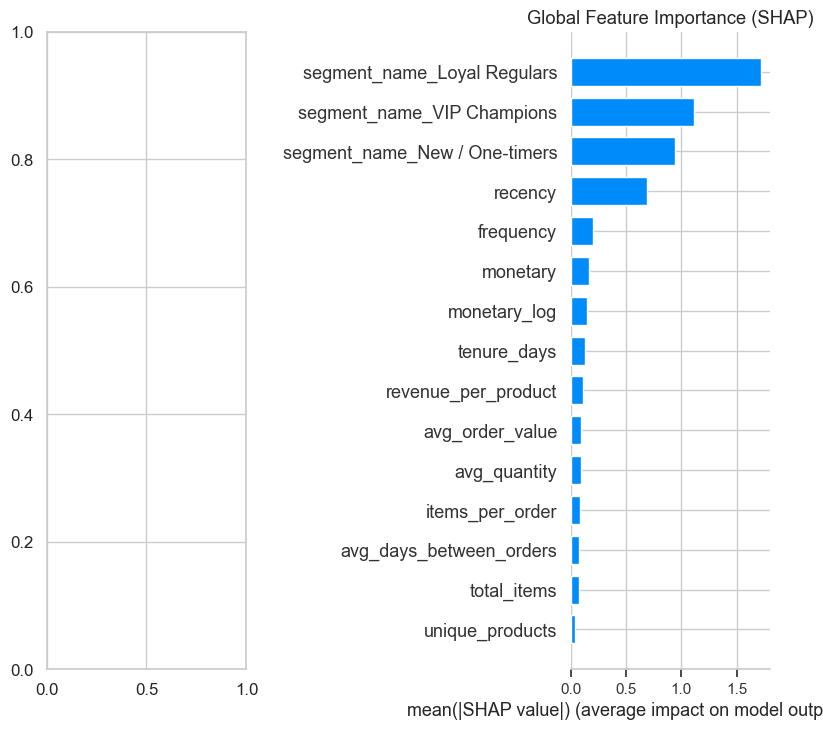

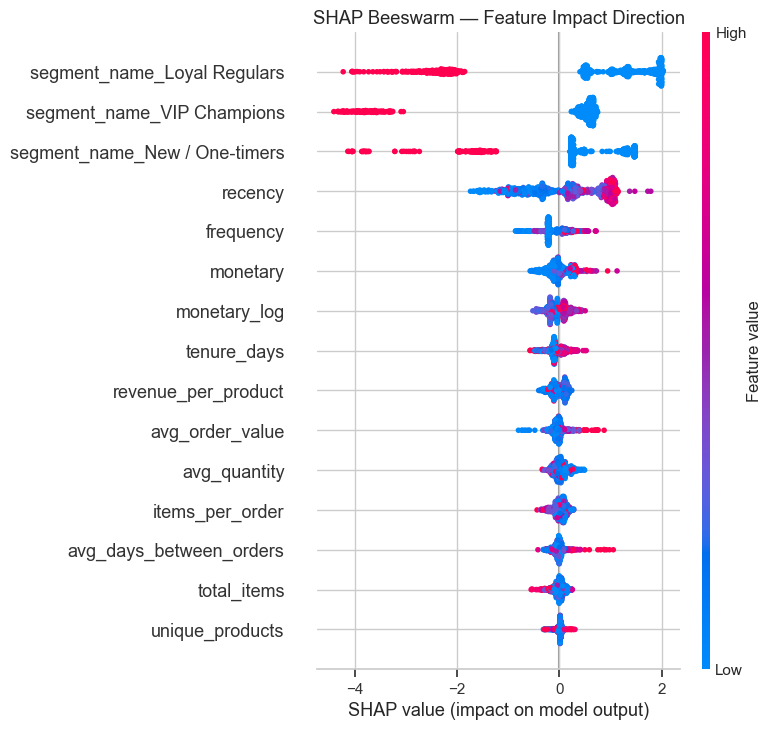

In [10]:
# ══════════════════════════════════════════════════════════
# SHAP — Explain WHY the model makes each prediction
# ══════════════════════════════════════════════════════════

# Get feature names after preprocessing
cat_feature_names = (
    preprocessor.transformers_[1][1]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
    .tolist()
)
all_feature_names = numeric_features + cat_feature_names

# Create SHAP explainer
explainer = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_val_processed)

# If binary classification returns list, take class 1
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# ── Global feature importance ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar plot — mean absolute SHAP
shap.summary_plot(
    shap_values, X_val_processed,
    feature_names=all_feature_names,
    plot_type="bar", max_display=15,
    show=False
)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig("../reports/10_shap_global.png", dpi=150, bbox_inches="tight")
plt.show()

# Beeswarm plot — direction + magnitude
shap.summary_plot(
    shap_values, X_val_processed,
    feature_names=all_feature_names,
    max_display=15, show=False
)
plt.title("SHAP Beeswarm — Feature Impact Direction")
plt.tight_layout()
plt.savefig("../reports/11_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()


══════════════════════════════════════════════════
  HIGH RISK CUSTOMER — Churn Prob: 0.999
══════════════════════════════════════════════════


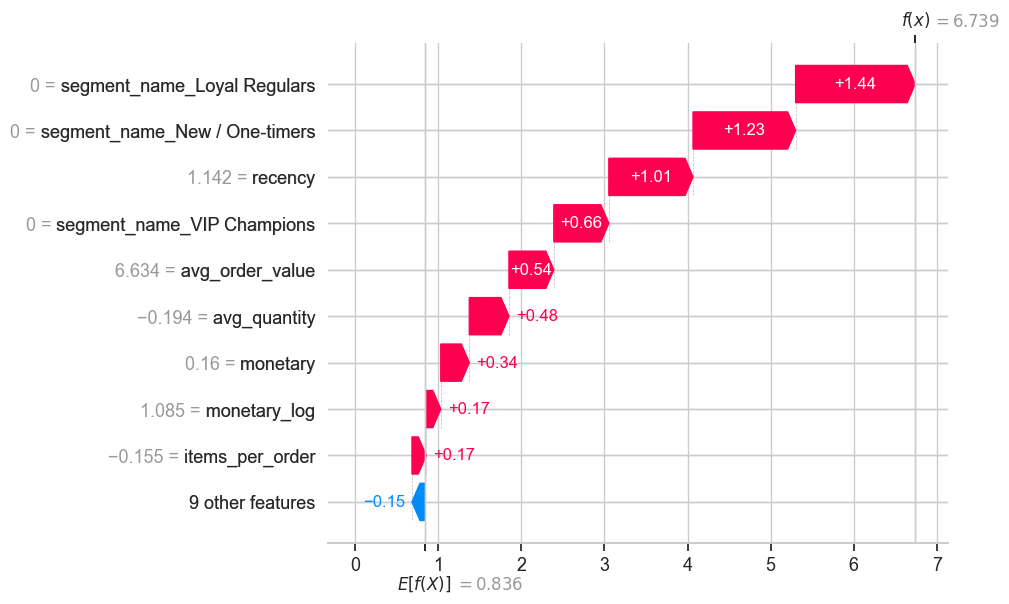


══════════════════════════════════════════════════
  LOW RISK CUSTOMER — Churn Prob: 0.008
══════════════════════════════════════════════════


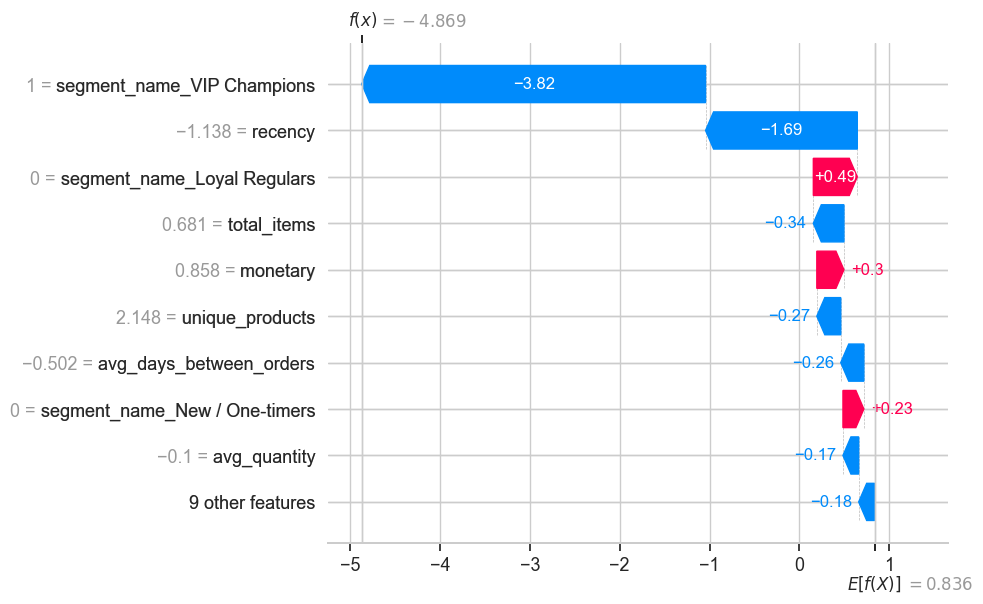


══════════════════════════════════════════════════
  BORDERLINE CUSTOMER — Churn Prob: 0.518
══════════════════════════════════════════════════


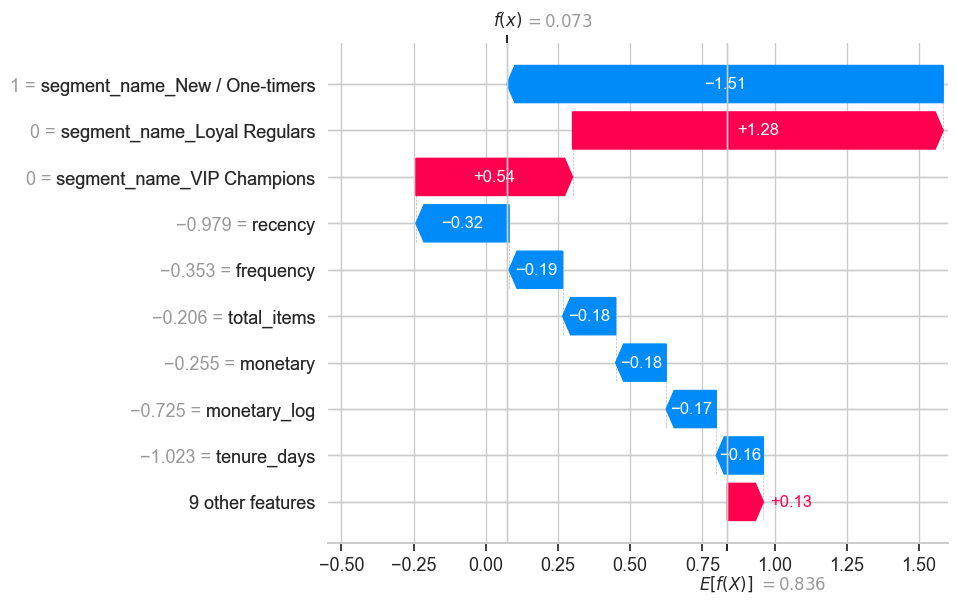

In [11]:
# ══════════════════════════════════════════════════════════
# Explain 3 individual predictions
# ══════════════════════════════════════════════════════════

# Pick 3 interesting customers from validation set
high_risk_idx  = np.argmax(y_champion_prob)      # highest churn probability
low_risk_idx   = np.argmin(y_champion_prob)       # lowest churn probability
mid_risk_idx   = np.argsort(y_champion_prob)[len(y_champion_prob)//2]  # middle

for label, idx in [("HIGH RISK", high_risk_idx),
                    ("LOW RISK", low_risk_idx),
                    ("BORDERLINE", mid_risk_idx)]:
    print(f"\n{'═' * 50}")
    print(f"  {label} CUSTOMER — Churn Prob: {y_champion_prob[idx]:.3f}")
    print(f"{'═' * 50}")

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value if not isinstance(
                explainer.expected_value, list
            ) else explainer.expected_value[1],
            data=X_val_processed[idx],
            feature_names=all_feature_names,
        ),
        max_display=10,
        show=True,
    )

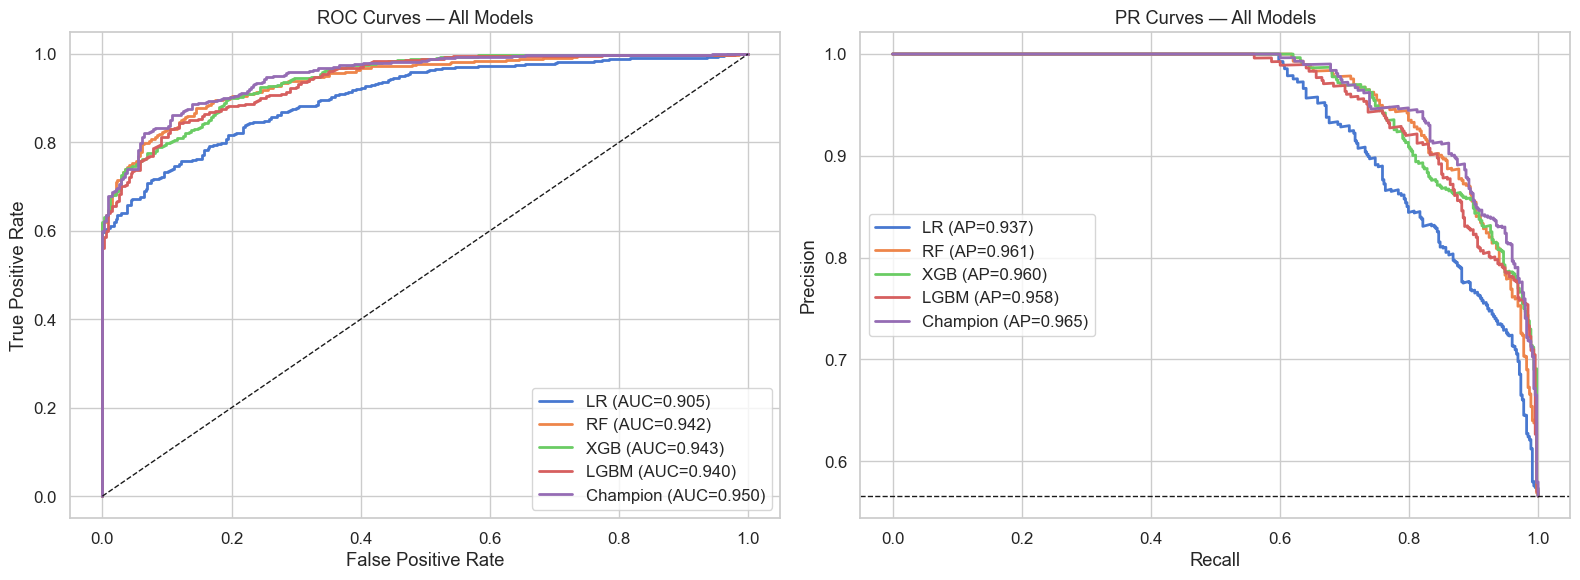


Champion saved → ../models/churn_champion.pkl

══════════════════════════════════════════════════
  WEEKEND 5 — FINAL RESULTS
══════════════════════════════════════════════════
          roc_auc_train  roc_auc_val  pr_auc_val  f1_val  accuracy_val
LR               0.8998       0.9046      0.9366  0.8015        0.8018
RF               0.9809       0.9425      0.9612  0.8651        0.8535
XGB              0.9998       0.9426      0.9597  0.8588        0.8422
LGBM             0.9999       0.9397      0.9577  0.8659        0.8510
Champion            NaN       0.9504      0.9652  0.8787        0.8699


In [12]:
# ══════════════════════════════════════════════════════════
# FINAL: Compare all ROC curves on one plot
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

all_models = {
    "LR":       lr_probs,
    "RF":       rf_probs,
    "XGB":      xgb_probs,
    "LGBM":     lgbm_probs,
    "Champion": y_champion_prob,
}

# ROC curves
for name, probs in all_models.items():
    fpr, tpr, _ = roc_curve(y_val, probs)
    auc = roc_auc_score(y_val, probs)
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — All Models")
axes[0].legend()

# PR curves
for name, probs in all_models.items():
    prec, rec, _ = precision_recall_curve(y_val, probs)
    ap = average_precision_score(y_val, probs)
    axes[1].plot(rec, prec, linewidth=2, label=f"{name} (AP={ap:.3f})")

axes[1].axhline(y=y_val.mean(), color="k", ls="--", linewidth=1)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("PR Curves — All Models")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/12_all_models_comparison.png", dpi=150)
plt.show()

# ── Save champion model ───────────────────────────────
model_path = Path("../models")
model_path.mkdir(exist_ok=True)

champion_bundle = {
    "model":        best_lgbm,
    "preprocessor": preprocessor,
    "features":     numeric_features + categorical_features,
    "best_params":  study.best_params,
    "metrics":      champion_metrics,
}
joblib.dump(champion_bundle, model_path / "churn_champion.pkl")
print(f"\nChampion saved → {model_path / 'churn_champion.pkl'}")

# ── Final summary ─────────────────────────────────────
print("\n══════════════════════════════════════════════════")
print("  WEEKEND 5 — FINAL RESULTS")
print("══════════════════════════════════════════════════")
all_results = {**results}
all_results["Champion"] = champion_metrics
final_df = pd.DataFrame(all_results).T
print(final_df.to_string())